<a href="https://colab.research.google.com/github/aman-5137/half_plasma/blob/main/_6_Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

df = pd.read_csv("/content/sample_data/heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [14]:
df.shape

(303, 14)

In [15]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [21]:
df.num.value_counts()

,count
num,
0,164
1,55
2,36
3,35
4,13


In [22]:
df['target'] = (df['num']>= 1).astype(int)

In [23]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [26]:
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [27]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Replace '?' with NaN in 'ca' and 'thal' columns
X = df.drop(columns=['num', 'target'])
for col in ['ca', 'thal']:
    if col in X.columns:
        X[col] = X[col].replace('?', np.nan).astype(float)

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

y = df['target']

X_scaled[:5]

array([[ 0.94872647,  0.68620244, -2.25177456,  0.75752504, -0.2649003 ,
         2.394438  ,  1.01668424,  0.01719733, -0.69663055,  1.08733806,
         2.27457861, -0.72309499,  0.65581797],
       [ 1.39200191,  0.68620244,  0.87798549,  1.61121989,  0.76041519,
        -0.41763453,  1.01668424, -1.82190531,  1.43548113,  0.39718162,
         0.64911323,  2.50385129, -0.89852225],
       [ 1.39200191,  0.68620244,  0.87798549, -0.6652997 , -0.34228261,
        -0.41763453,  1.01668424, -0.90235399,  1.43548113,  1.34614673,
         0.64911323,  1.42820253,  1.17393137],
       [-1.93256387,  0.68620244, -0.16526786, -0.0961698 ,  0.06397448,
        -0.41763453, -0.99674925,  1.63735918, -0.69663055,  2.12257273,
         2.27457861, -0.72309499, -0.89852225],
       [-1.48928843, -1.4572959 , -1.20852121, -0.0961698 , -0.82592199,
        -0.41763453,  1.01668424,  0.98053681, -0.69663055,  0.31091206,
        -0.97635214, -0.72309499, -0.89852225]])

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print('Train patients', X_train.shape[0])
print('Test patients', X_test.shape[0])

Train patients 242
Test patients 61


In [39]:
from sklearn.svm import SVC
model = SVC(kernel='rbf')
model.fit(X_test, y_test)

SVC()

In [36]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names =['no disease (0)', 'disease (1)']))


                precision    recall  f1-score   support

no disease (0)       0.97      0.94      0.95        33
   disease (1)       0.93      0.96      0.95        28

      accuracy                           0.95        61
     macro avg       0.95      0.95      0.95        61
  weighted avg       0.95      0.95      0.95        61



In [37]:
# In disease pridiction note that the recall must be higher than precission
'''Truth = [1,0,0,0,1,0,1]
Prediction = [1,0,0,1,1,0,1]
'''


'Truth = [1,0,0,0,1,0,1]\nPrediction = [1,0,0,1,1,0,1]\n'

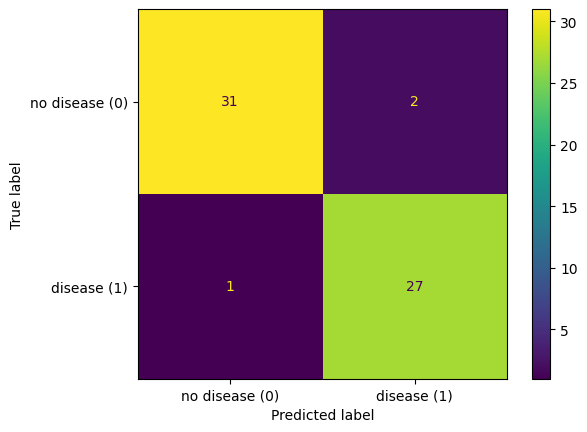

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no disease (0)', 'disease (1)'])
disp.plot()
plt.show()

In [42]:
# Train the same SVM with different C and gamma values and compare
configs= [
    (1.0, 'scale'),
    (1.0, 'auto'),
    (10.0, 'scale'),
    (10.0, 'auto'),
    (100.0, 'scale'),
    (100.0, 'auto')
]
for C, gamma in configs:
  m= SVC(C=C, gamma=gamma)
  m.fit(X_train, y_train)
  y_pred = m.predict(X_test)
  print(f'C={C}, gamma={gamma}')
  print(classification_report(y_test, y_pred, target_names=['no disease', 'disease']))

C=1.0, gamma=scale
              precision    recall  f1-score   support

  no disease       0.90      0.82      0.86        33
     disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

C=1.0, gamma=auto
              precision    recall  f1-score   support

  no disease       0.90      0.82      0.86        33
     disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

C=10.0, gamma=scale
              precision    recall  f1-score   support

  no disease       0.96      0.67      0.79        33
     disease       0.71      0.96      0.82        28

    accuracy                           0.80        61
   macro avg       0.83      0.82      0.80        61
weighted avg     

In [43]:
# We have C = 100, gamma = scale as the best result we could get from our model